### Installation and setup

In [1]:
!pip install langgraph langsmith


   ------ --------------------------------- 1/6 [langgraph-sdk]
   ------ --------------------------------- 1/6 [langgraph-sdk]
   ------ --------------------------------- 1/6 [langgraph-sdk]
  Attempting uninstall: langchain-core
   ------ --------------------------------- 1/6 [langgraph-sdk]
    Found existing installation: langchain-core 0.3.74
   ------ --------------------------------- 1/6 [langgraph-sdk]
   ------------- -------------------------- 2/6 [langchain-core]
   ------------- -------------------------- 2/6 [langchain-core]
    Uninstalling langchain-core-0.3.74:
   ------------- -------------------------- 2/6 [langchain-core]
      Successfully uninstalled langchain-core-0.3.74
   ------------- -------------------------- 2/6 [langchain-core]
   ------------- -------------------------- 2/6 [langchain-core]
   ------------- -------------------------- 2/6 [langchain-core]
   ------------- -------------------------- 2/6 [langchain-core]
   ------------- --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.1.0 which is incompatible.
langchain-community 0.3.27 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 1.1.0 which is incompatible.
langchain-groq 0.3.7 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.1.0 which is incompatible.
langchain-huggingface 0.3.1 requires langchain-core<1.0.0,>=0.3.70, but you have langchain-core 1.1.0 which is incompatible.
langchain-nvidia-ai-endpoints 0.3.16 requires langchain-core<0.4,>=0.3.51, but you have langchain-core 1.1.0 which is incompatible.
langchain-openai 0.3.29 requires langchain-core<1.0.0,>=0.3.74, but you have langchain-core 1.1.0 which is incompatible.
langchain-text-splitters 0.3.9 requires langchain-core<1.0.0,>=0.3.72, but you have langcha

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [5]:
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "CourseLanggraph"

In [6]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")

### Start building Chatboit using Langgraph

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    # Automatically add message history management
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [9]:
graph_builder

In [10]:
def chatbot(state:State):
    return {"messages":llm.invoke(state["messages"])}

In [11]:
graph_builder.add_node("chatbot",chatbot)

In [12]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [13]:
graph = graph_builder.compile()

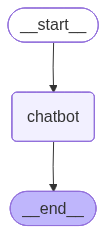

In [14]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass

In [15]:
while True:
    user_query = input("User: ")
    if user_query.lower() in ["exit","quit","q"]:
        print("Exiting chat.")
        break
    
    for event in graph.stream({'messages':("user",user_query)}):
        print(event.values())
        for value in event.values():
            print(value['messages'])
            print("Assistant:", value['messages'].content)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


dict_values([{'messages': AIMessage(content="Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 36, 'total_tokens': 61, 'completion_time': 0.046576323, 'prompt_time': 0.001664595, 'queue_time': 0.063475774, 'total_time': 0.048240918}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--e419f854-d5cf-4431-8466-06e08aced9a7-0', usage_metadata={'input_tokens': 36, 'output_tokens': 25, 'total_tokens': 61})}])
content="Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 36, 'total_tokens': 61, 'completion_time': 0.046576323, 'prompt_time': 0.001664595, 'queue_time': 0.063475774, 'total_time': 0.0

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


dict_values([{'messages': AIMessage(content='The first president of the United States was George Washington. He was inaugurated on April 30, 1789, and served two terms in office until March 4, 1797. Washington is often referred to as the "Father of the Country" and is widely regarded as one of the most important figures in American history. He played a key role in the American Revolution and was a dominant figure in the drafting and ratification of the United States Constitution.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 45, 'total_tokens': 139, 'completion_time': 0.209387357, 'prompt_time': 0.002227231, 'queue_time': 0.160157978, 'total_time': 0.211614588}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--f7ee3a5c-ea8e-4205-ad60-0cccebc53689-0', usage_metadata={'input_tokens': 45, 'output_tokens': 94, 'total_toke

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Exiting chat.
